In [297]:
import numpy as np
import jax
import jax.numpy as jnp
from flax import nnx
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import optax
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset

from cbm import GaussianLangevinMechanism, MacroCausalVar, SCBM

In [265]:
# global seed, random states
seed = 0
rs = np.random.RandomState(seed=seed)

In [266]:
jax.devices()

[METAL(id=0)]

In [328]:
# Define data model
# 2D
M = np.ones((2, 2)) # 2 variables are always fully connected

# X1
n1 = 2
P1 = sample_mrf_prec(dim=n1, M=M, rs=rs)
mech1 = GaussianLangevinMechanism(mu=np.zeros(n1), E=np.linalg.inv(P1))
X1 = MacroCausalVar(parents=None, bottleneck_fcts=None, mechanism=mech1, n=n1)

# X2
# Bottleneck function
f_y12 = lambda X: X[:, 0]**2 + X[:, 1]**2 # TODO: something is wrong with the shape here

n2 = 2
P2 = sample_mrf_prec(dim=n2, M=M, rs=rs)
alpha = 3
mu2 = lambda x: [alpha * x_elem * np.ones(n2) for x_elem in x]
mech2 = GaussianLangevinMechanism(mu=mu2, E=np.linalg.inv(P2))
X2 = MacroCausalVar(parents=[X1], bottleneck_fcts=[f_y12], mechanism=mech2, n=n2)

scbm1 = SCBM(variables=[X1, X2], seed=seed)

In [329]:
sample = scbm1.sample(size=10000)

In [330]:
# Dataset class
class CBMDataset(Dataset):
    def __init__(self, *data):
        super().__init__()
        self.data = data

    def __len__(self):
        return len(self.data[0])

    def __getitem__(self, idx):
        if len(self.data) == 1: # If there is only one element in the list
            return self.data[0][idx]
        else:
            return [var[idx] for var in self.data]

In [331]:
def numpy_collate(batch):
    if isinstance(batch[0], np.ndarray):
        return np.stack(batch)
    elif isinstance(batch[0], (tuple,list)):
        transposed = zip(*batch)
        return [numpy_collate(samples) for samples in transposed]
    else:
        return np.array(batch)

In [332]:
# Split data into train/test
X1_train, X1_test, X2_train, X2_test = train_test_split(*sample, test_size=0.2, random_state=rs)

bs = 128

train_dataloader = DataLoader(CBMDataset(X1_train, X2_train), batch_size=bs, shuffle=True, collate_fn=numpy_collate)
test_dataloader = DataLoader(CBMDataset(X1_test), batch_size=bs, shuffle=False, collate_fn=numpy_collate)


In [333]:
# Define model
class BottleneckAutoencoder(nnx.Module):
    """Simple autoencoder model."""
    def __init__(self, in_dim, dense_x_y, y_dim, out_dim, rngs):
        key = rngs.params()

        # Encoder params
        layers_MLP = []
        for i in range(len(dense_x_y)):
            if i == 0:
                layers_MLP.append(nnx.Linear(in_dim, dense_x_y[i], rngs=rngs))
            else:
                layers_MLP.append(nnx.Linear(dense_x_y[i-1], dense_x_y[i], rngs=rngs))
            layers_MLP.append(nnx.swish)
            # Not using any dropout for this simple model
        layers_MLP.append(nnx.Linear(dense_x_y[-1], y_dim, rngs=rngs))
        self.encoder = nnx.Sequential(*layers_MLP)

        # Decoder params
        self.alpha = nnx.Param(jax.random.uniform(key))
        self.out_dim = out_dim

    def encode(self, x):
        return self.encoder(x)

    def decode(self, y):
        return self.alpha * y * jnp.ones(self.out_dim)

    def __call__(self, x):
        x = self.encode(x)
        x = self.decode(x)
        return x

In [334]:
model = BottleneckAutoencoder(in_dim=2, dense_x_y=[128, 128], y_dim=1, out_dim=2, rngs=nnx.Rngs(params=seed))

In [335]:
# Optimizer
lr = 0.005
momentum = 0.9

optimizer = nnx.Optimizer(model, optax.adamw(lr, momentum))

In [336]:
# Loss function
def loss_fn(model, in_batch, target_batch):
    out_batch = model(in_batch)
    loss = ((out_batch - target_batch)**2).mean()
    return loss # can also output more than just the loss (for some logging etc)

In [337]:
@nnx.jit
def train_step(model, optimizer, in_batch, target_batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=False)
    loss, grads = grad_fn(model, in_batch, target_batch)
    optimizer.update(grads)

In [338]:
@nnx.jit
def inference_step(model, in_batch):
    y_batch = model.encode(in_batch)
    return y_batch

In [339]:
# Train loop
epochs = 5

for epoch in range(epochs):
    for train_in_batch, train_target_batch in train_dataloader:
        train_step(model, optimizer, train_in_batch, train_target_batch)

In [340]:
# Encode test set with trained model
y_list = []
for test_in_batch in test_dataloader:
    y_batch = inference_step(model, test_in_batch)
    y_list.append(y_batch)

y_test = jnp.concatenate(y_list)

In [341]:
def visualize_bottleneck_embedding(x, y):
    """
    Args:
        x: np.array
            Input values that get embedded
        y: np.array
            Embedded inputs
        y_min/max: float
            Min/max values for color rescaling
    """
    fig, ax = plt.subplots()

    ax.scatter(x[:, 0], x[:, 1], c=y)

    plt.show()

In [292]:
# Normalizing for scatter plots
y_min = np.min((np.min(y_test), np.min(f_y12(X1_test))))
y_max = np.max((np.max(y_test), np.max(f_y12(X1_test))))

In [294]:
y_max

29.75830078125

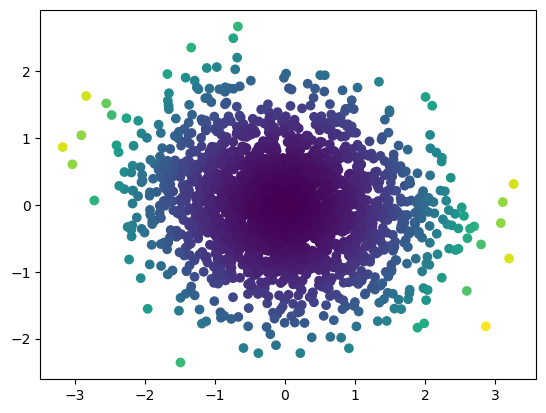

In [342]:
visualize_bottleneck_embedding(X1_test, f_y12(X1_test))

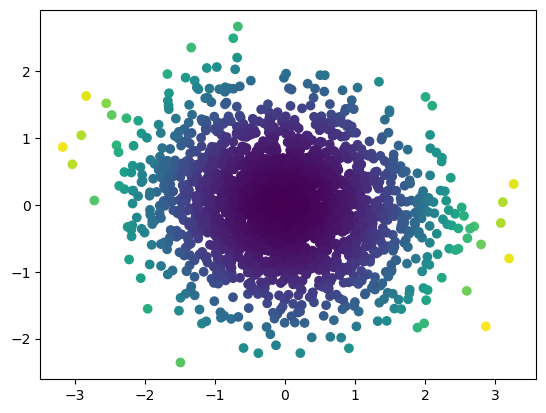

In [343]:
visualize_bottleneck_embedding(X1_test, y_test)

In [131]:
nnx.display(model)

BottleneckAutoencoder(
  encoder=Sequential(
    layers=[Linear(
      kernel=Param(
        value=Array(shape=(2, 128), dtype=float32)
      ),
      bias=Param(
        value=Array(shape=(128,), dtype=float32)
      ),
      in_features=2,
      out_features=128,
      use_bias=True,
      dtype=None,
      param_dtype=<class 'jax.numpy.float32'>,
      precision=None,
      kernel_init=<function variance_scaling.<locals>.init at 0x12fc61090>,
      bias_init=<function zeros at 0x11a8c7b50>,
      dot_general=<function dot_general at 0x10ff5f640>
    ), <PjitFunction of <function silu at 0x11a8d24d0>>, Linear(
      kernel=Param(
        value=Array(shape=(128, 128), dtype=float32)
      ),
      bias=Param(
        value=Array(shape=(128,), dtype=float32)
      ),
      in_features=128,
      out_features=128,
      use_bias=True,
      dtype=None,
      param_dtype=<class 'jax.numpy.float32'>,
      precision=None,
      kernel_init=<function variance_scaling.<locals>.init at 0x12f

In [123]:
x_hat = model(jnp.ones((16,2)))

In [126]:
y_hat = model.encode(jnp.ones((16,2)))

In [124]:
x_hat.shape

(16, 2)

In [129]:
nnx.display(y_hat)

[[-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]
 [-0.48653096]]
